<a href="https://colab.research.google.com/github/mcarden4-netizen/Homework-Intro-to-ML/blob/Homework/Homework1Part1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [282]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')

filetest = '/content/drive/My Drive/D3.csv'
data = pd.DataFrame(pd.read_csv(filetest))
data.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,X1,X2,X3,Y
0,0.000000,3.440000,0.440000,4.387545
1,0.040404,0.134949,0.888485,2.679650
2,0.080808,0.829899,1.336970,2.968490
3,0.121212,1.524848,1.785455,3.254065
4,0.161616,2.219798,2.233939,3.536375


In [283]:
x1 = data.values[:,0]
x2 = data.values[:,1]
x3 = data.values[:,2]
Y = data.values[:,3]

a = len(x1)

In [284]:
x1_0 = np.ones((a, 1))
x2_0 = np.ones((a, 1))
x3_0 = np.ones((a, 1))

In [285]:
x1_1 = x1.reshape(a,1)
x2_1 = x2.reshape(a,1)
x3_1 = x3.reshape(a,1)


In [286]:
x1 = np.hstack((x1_0, x1_1))
x2 = np.hstack((x2_0, x2_1))
x3 = np.hstack((x3_0, x3_1))


In [287]:
def determine_data(input_data, output_data, theta):

  Predictions = input_data.dot(theta)
  Errors = np.subtract(Predictions, output_data)
  Squared_Errors = np.square(Errors)
  C = 1/(2*a) * np.sum(Squared_Errors)

  return C

In [288]:
def gradient_descent(input_data , output_data, theta, alpha, instances):

  b = len(x1)

  data_history = np.zeros(instances)

  for i in range(instances):

    Predictions = input_data.dot(theta)
    Errors = np.subtract(Predictions, output_data)
    Gradient = (alpha/b) * (input_data.T.dot(Errors))
    theta = theta - Gradient
    data_history[i] = determine_data(input_data, output_data, theta)


  return theta, data_history

In [289]:
theta = [0.,0.]
instances = 1000
alpha = .01
alpha2 = .001
alpha3 = .03

In [290]:
theta1, data_history1 = gradient_descent(x1, Y, theta, alpha, instances)
theta1_2, data_history1_2 = gradient_descent(x1, Y, theta, alpha2, instances)
theta1_3, data_history1_3 = gradient_descent(x1, Y, theta, alpha3, instances)

In [291]:
theta2, data_history2 = gradient_descent(x2, Y, theta, alpha, instances)
theta2_2, data_history2_2 = gradient_descent(x2, Y, theta, alpha2, instances)
theta2_3, data_history2_3 = gradient_descent(x2, Y, theta, alpha3, instances)

In [292]:
theta3, data_history3 = gradient_descent(x3, Y, theta, alpha3, instances)
theta3_2, data_history3_2 = gradient_descent(x3, Y, theta, alpha2, instances)
theta3_3, data_history3_3 = gradient_descent(x3, Y, theta, alpha, instances)

In [293]:
print("Model using X1:")
print("Y =", theta1[0], "+", theta1[1], 'x1')

print("Model using X2:")
print("Y =", theta2[0], "+", theta2[1], 'x2')

print("Model using X3:")
print("Y =", theta3[0], "+", theta3[1], 'x3')

print('\n')

print("Final Losses:")
print("X1:", data_history1[-1])
print("X2:", data_history2[-1])
print("X3:", data_history3[-1])

Model using X1:
Y = 5.2929472827573 + -1.7911907900332469 x1
Model using X2:
Y = 0.687019946445204 + 0.5766946227869244 x2
Model using X3:
Y = 2.868361265669971 + -0.51927234013648 x3


Final Losses:
X1: 1.0364360799429273
X2: 3.5996728289711006
X3: 3.6294523425348615


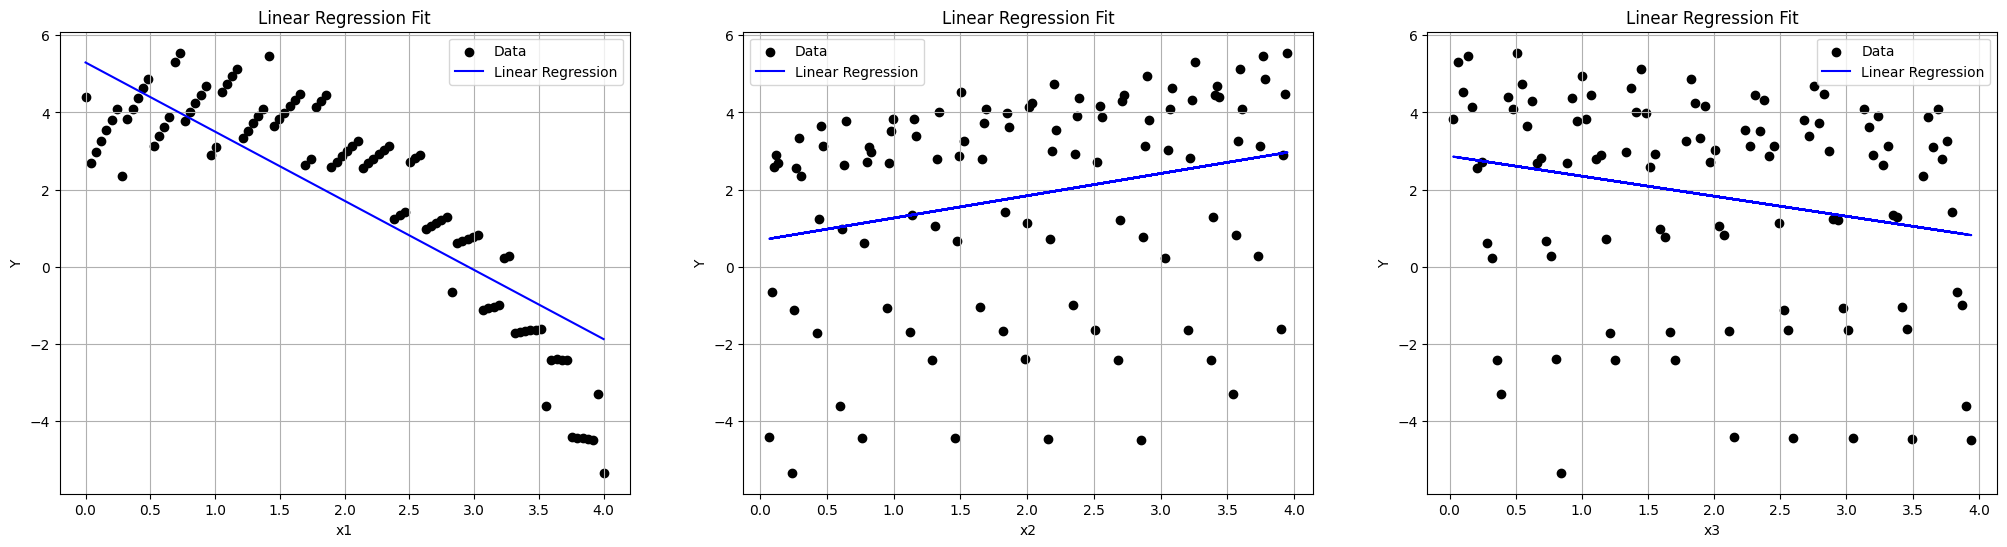

In [294]:
plt.figure(figsize=(25,6))

plt.subplot(1,3,1)
plt.scatter(x1[:, 1], Y, color='black', label='Data')
plt.plot(x1[:, 1], x1.dot(theta1), color='blue', label='Linear Regression')
plt.grid(True)
plt.xlabel('x1')
plt.ylabel('Y')
plt.title('Linear Regression Fit')
plt.legend()

plt.subplot(1,3,2)
plt.scatter(x2[:, 1], Y, color='black', label='Data')
plt.plot(x2[:, 1], x2.dot(theta2), color='blue', label='Linear Regression')
plt.grid(True)
plt.xlabel('x2')
plt.ylabel('Y')
plt.title('Linear Regression Fit')
plt.legend()

plt.subplot(1,3,3)
plt.scatter(x3[:, 1], Y, color='black', label='Data')
plt.plot(x3[:, 1], x3.dot(theta3), color='blue', label='Linear Regression')
plt.grid(True)
plt.xlabel('x3')
plt.ylabel('Y')
plt.title('Linear Regression Fit')
plt.legend()

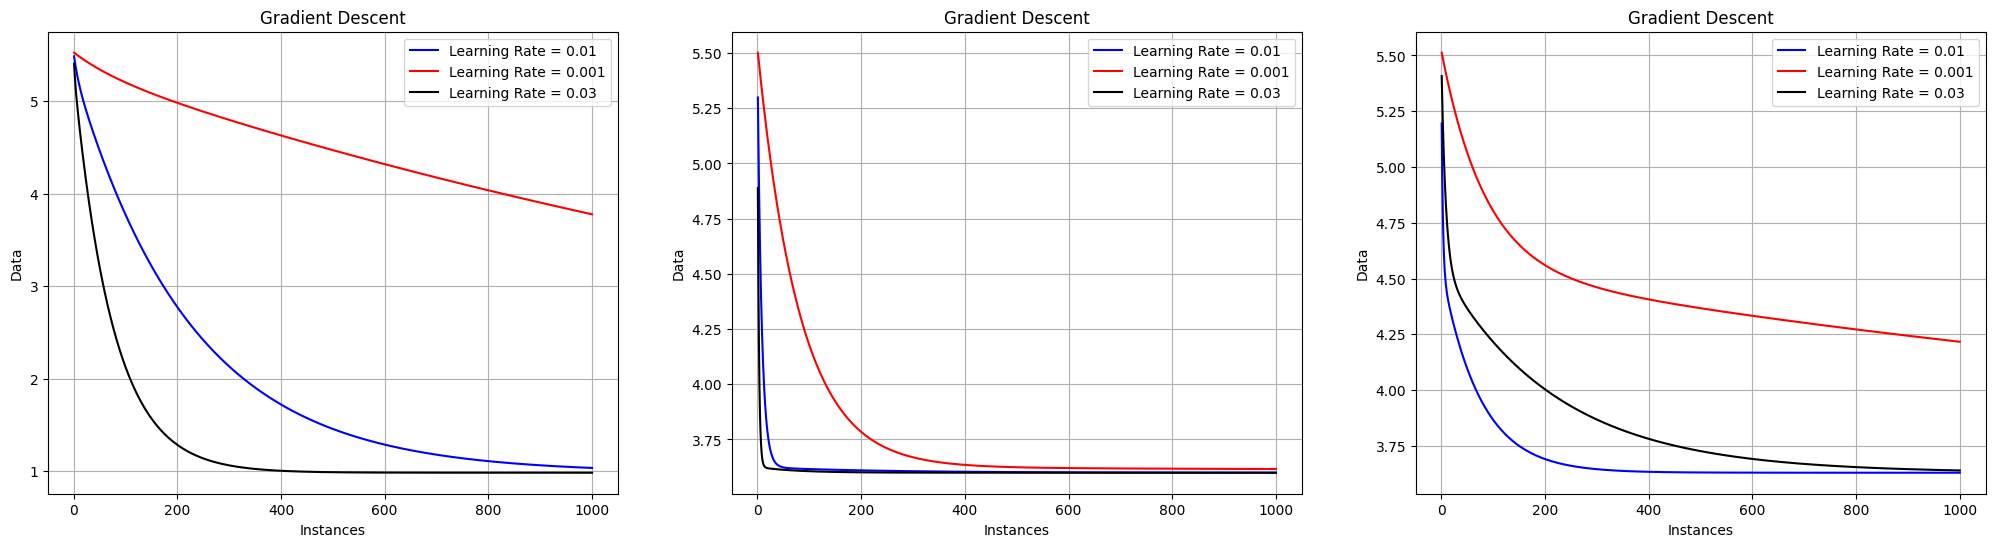

In [295]:
plt.figure(figsize=(25,6))

plt.subplot(1,3,1)
plt.plot(range(1, instances + 1), data_history1, color='blue')
plt.plot(range(1, instances + 1), data_history1_2, color='red')
plt.plot(range(1, instances + 1), data_history1_3, color='black')
plt.grid(True)
plt.xlabel('Instances')
plt.ylabel('Data')
plt.title('Gradient Descent')
plt.legend(['Learning Rate = 0.01', 'Learning Rate = 0.001', 'Learning Rate = 0.03'])

plt.subplot(1,3,2)
plt.plot(range(1, instances + 1), data_history2, color='blue')
plt.plot(range(1, instances + 1), data_history2_2, color='red')
plt.plot(range(1, instances + 1), data_history2_3, color='black')
plt.grid(True)
plt.xlabel('Instances')
plt.ylabel('Data')
plt.title('Gradient Descent')
plt.legend(['Learning Rate = 0.01', 'Learning Rate = 0.001', 'Learning Rate = 0.03'])

plt.subplot(1,3,3)
plt.plot(range(1, instances + 1), data_history3, color='blue')
plt.plot(range(1, instances + 1), data_history3_2, color='red')
plt.plot(range(1, instances + 1), data_history3_3, color='black')
plt.grid(True)
plt.xlabel('Instances')
plt.ylabel('Data')
plt.title('Gradient Descent')
plt.legend(['Learning Rate = 0.01', 'Learning Rate = 0.001', 'Learning Rate = 0.03'])
